Objective


-Detect object boundaries using grayscale conversion, Gaussian blur, Canny edge detection, and contour detection.

-Recommended Images:

Coins, fruits, shapes, stationery, or any image with clear object boundaries.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


Step 1: Upload an Image

In [ ]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print("Uploaded image:", image_path)

Saving 23255-4-george-clooney-image.png to 23255-4-george-clooney-image.png
Uploaded image: 23255-4-george-clooney-image.png


Step 2: Read and Display Original Image

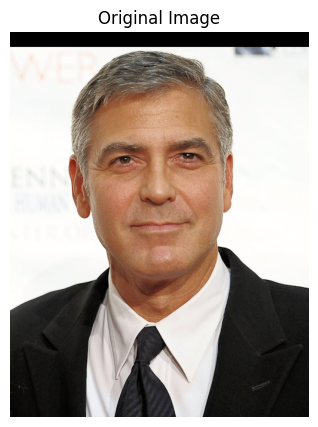

Image shape: (644, 500, 3)


In [ ]:
img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise ValueError("Image could not be loaded.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7,5))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

print("Image shape:", img_rgb.shape)

Step 3: Convert to Grayscale

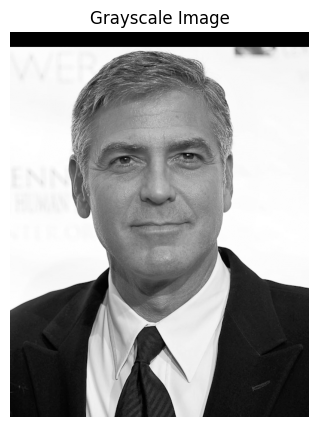

In [ ]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(7,5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

Step 4: Apply Gaussian Blur


-Blurring reduces noise before edge detection.

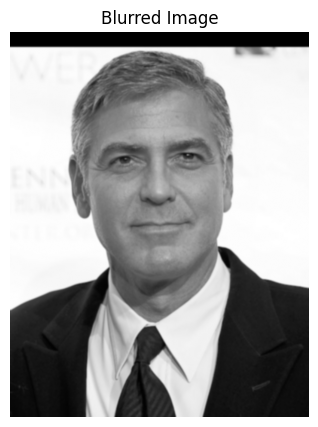

In [ ]:
blur = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(7,5))
plt.imshow(blur, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")
plt.show()

Step 5: Apply Canny Edge Detection

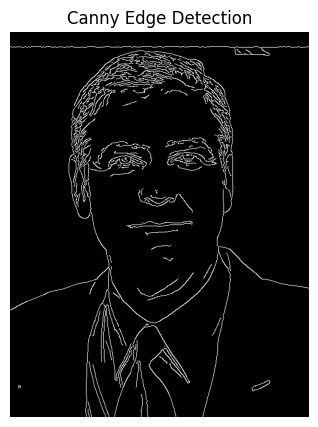

In [21]:
low_threshold = 50    # we can lower threshold to capture missing contours
high_threshold = 100

edges = cv2.Canny(blur, low_threshold, high_threshold)

plt.figure(figsize=(7,5))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

Step 6: Find and Draw Contours

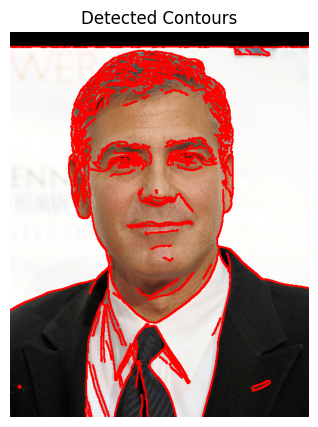

Total contours detected: 234


In [22]:
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = img_rgb.copy()
cv2.drawContours(output, contours, -1, (255, 0, 0), 2)

plt.figure(figsize=(7,5))
plt.imshow(output)
plt.title("Detected Contours")
plt.axis("off")
plt.show()

print("Total contours detected:", len(contours))

Step 7: Filter Small Contours


-Sometimes noise creates small contours. We remove very small areas.

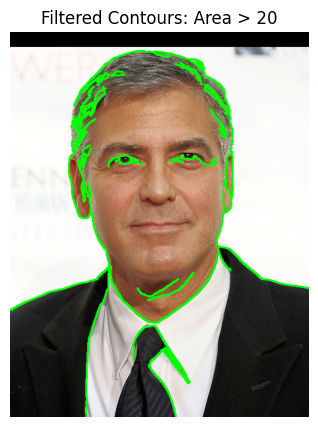

Filtered object count: 20


In [29]:
min_area = 20      # Lowered min_area to capture more details

filtered_contours = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > min_area:
        filtered_contours.append(cnt)

filtered_output = img_rgb.copy()
cv2.drawContours(filtered_output, filtered_contours, -1, (0, 255, 0), 2)

plt.figure(figsize=(7,5))
plt.imshow(filtered_output)
plt.title(f"Filtered Contours: Area > {min_area}")
plt.axis("off")
plt.show()

print("Filtered object count:", len(filtered_contours))

Step 8: Draw Bounding Boxes around Contours

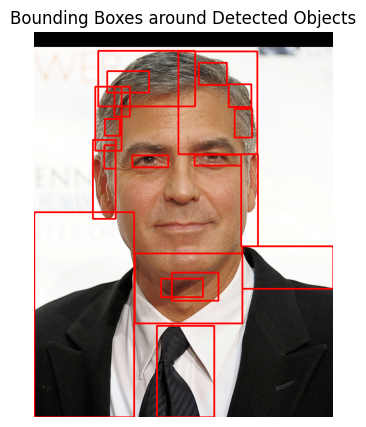

In [30]:
box_output = img_rgb.copy()

for cnt in filtered_contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(box_output, (x, y), (x+w, y+h), (255, 0, 0), 2)

plt.figure(figsize=(7,5))
plt.imshow(box_output)
plt.title("Bounding Boxes around Detected Objects")
plt.axis("off")
plt.show()

Step 9: Display Complete Workflow

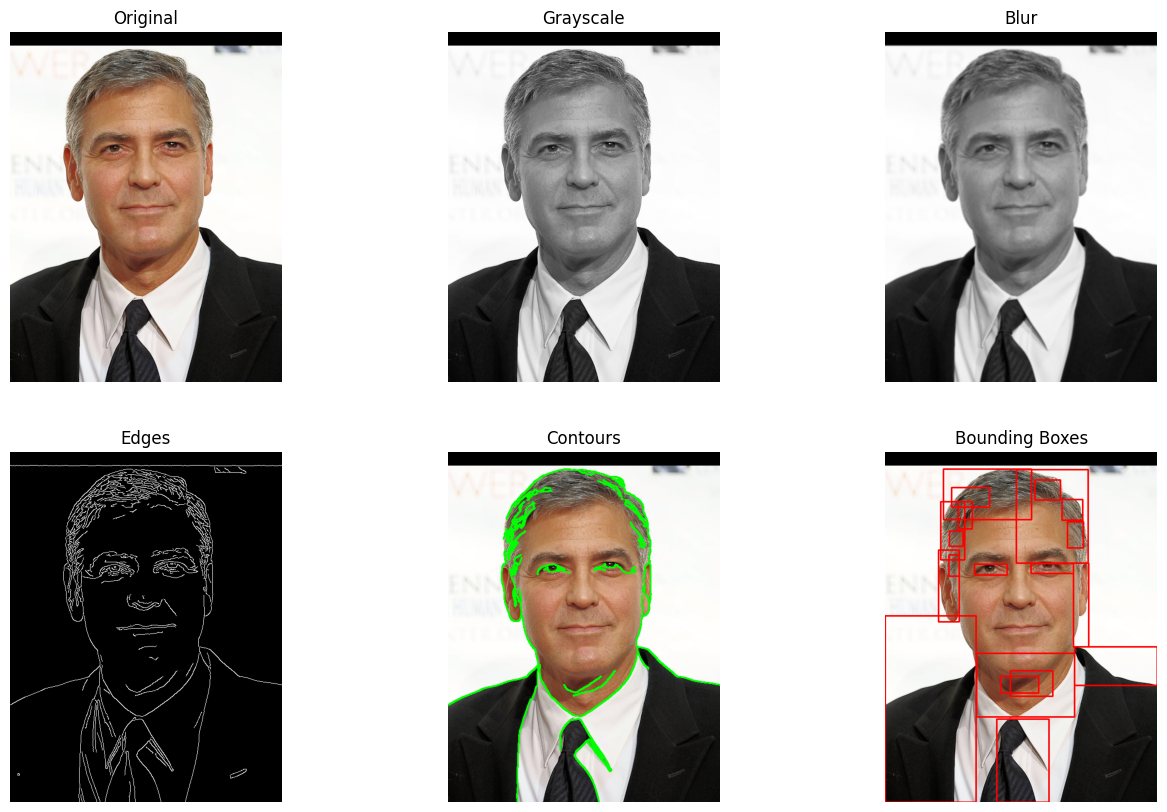

In [31]:
plt.figure(figsize=(16,10))

plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(blur, cmap="gray")
plt.title("Blur")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(filtered_output)
plt.title("Contours")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(box_output)
plt.title("Bounding Boxes")
plt.axis("off")

plt.show()

In [ ]:
#Student Conclusion
#Write your answers:

#What is an edge in an image?
#Why do we apply blur before Canny edge detection?
#How many objects/contours were detected?
#What happens when you change low_threshold and high_threshold?
#Mention two real-life applications of edge detection.